# Natural Language Processing Pipeline and Text Classification

## Business Problem

MapleMart is an online retail company that collects customer feedback across multiple channels, its website, mobile app, email surveys, and social media. Each review is short, free-text, and is accompanied by a sentiment label ("positive," "negative," or "neutral").

Manually reading every review at scale is not feasible. The business needs an automated way to:

1. **Classify each incoming review** into one of three sentiment categories.
2. **Surface negative reviews quickly** so that customer-service managers can intervene before dissatisfaction escalates into churn or public complaints.
3. **Monitor overall satisfaction trends** by channel, product category, and city.

This notebook builds a basic NLP pipeline, preprocessing, exploratory analysis, feature extraction, and a supervised classifier to demonstrate how raw review text can be turned into a decision-support signal for the business.

In [1]:
import warnings, string, re
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'maxent_ne_chunker', 'maxent_ne_chunker_tab', 'words']:
    nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_colwidth', 200)
RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


## Task 1: Load and Inspect the Dataset

In [2]:
# Load dataset
df = pd.read_csv("NLP Customer Review Sentiment.csv")

print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== Dataset Shape ===
Rows: 120, Columns: 8


In [4]:
print("=== Column Names ===")
print(list(df.columns))

=== Column Names ===
['ReviewID', 'ReviewDate', 'Channel', 'City', 'ProductCategory', 'CustomerSegment', 'ReviewText', 'SentimentLabel']


In [5]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
ReviewID           0
ReviewDate         0
Channel            0
City               0
ProductCategory    0
CustomerSegment    0
ReviewText         0
SentimentLabel     0
dtype: int64


In [6]:
print("=== Target Variable Distribution ===")
dist = df['SentimentLabel'].value_counts()
print(dist)

=== Target Variable Distribution ===
SentimentLabel
Positive    40
Neutral     40
Negative    40
Name: count, dtype: int64


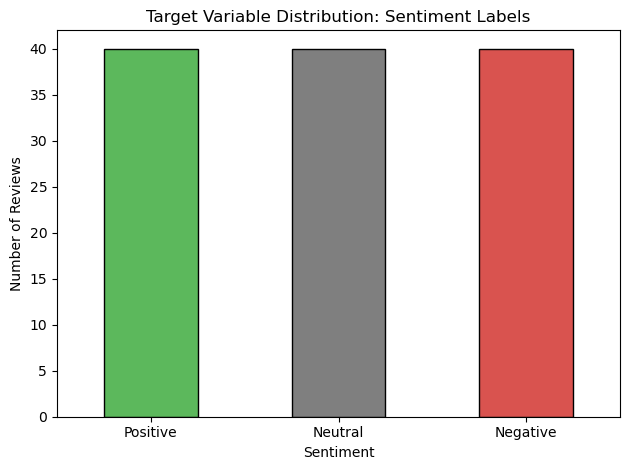

In [9]:
# Visualize target distribution
ax = df['SentimentLabel'].value_counts().reindex(['Positive', 'Neutral', 'Negative']).plot(
    kind='bar', color=['#5cb85c', '#7f7f7f', '#d9534f'], edgecolor='black')
ax.set_title('Target Variable Distribution: Sentiment Labels')
ax.set_ylabel('Number of Reviews')
ax.set_xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df.head()

,ReviewID,ReviewDate,Channel,City,ProductCategory,CustomerSegment,ReviewText,SentimentLabel
0,REV-001,2026-01-06,Mobile App,Oshawa,Accessories,Returning Customer,"The Accessories item looked better than expected. Delivery to Oshawa was smooth, and I am very happy with the purchase. #customerreview",Positive
1,REV-002,2026-01-07,Email Survey,Hamilton,Beauty,Student,The website checkout was simple. I may buy again if the price is lower next time.,Neutral
2,REV-003,2026-01-08,Social Media,Waterloo,Home,Premium Member,"The package arrived on June 5. It was not amazing, but there were no major problems.",Neutral
3,REV-004,2026-01-09,Website,Oshawa,Beauty,New Customer,The website checkout was simple. I may buy again if the price is lower next time.,Neutral
4,REV-005,2026-01-10,Mobile App,Hamilton,Home,Returning Customer,"The Home product arrived in Hamilton. It works as expected, but I have not used it enough to judge the quality.",Neutral


## Dataset Description

The dataset contains **120 reviews** with **no missing values** in any column. Classes are **perfectly balanced** (40 records each). This is convenient for training but is a property of the synthetic dataset and would not be expected on real-world review data. The text column contains punctuation, mixed case, hashtags (e.g. `#customerreview`), city names, dates, and the brand "MapleMart" all of which the preprocessing step will handle.

| Column | Meaning | Role in this notebook |
|---|---|---|
| `ReviewID` | Unique identifier for each review | Identification only, not a feature |
| `ReviewDate` | Date the review was collected | Contextual; not modelled |
| `Channel` | Source of the review (Website, Mobile App, Email Survey, Social Media) | Useful for business interpretation |
| `City` | City mentioned in the review | Relevant for NER discussion |
| `ProductCategory` | Type of product purchased | Useful for slicing insights |
| `CustomerSegment` | Customer cohort (New, Returning, Premium Member, Student) | Contextual |
| **`ReviewText`** | **The free-text review** | **Main NLP input feature** |
| **`SentimentLabel`** | **Positive / Neutral / Negative** | **Target variable for classification** |


## Task 2: Text Preprocessing

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'#\w+', ' ', text)                 # hashtags
    text = re.sub(r'\d+', ' ', text)                  # digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens
              if t.isalpha() and t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['CleanedText'] = df['ReviewText'].apply(preprocess)
df[['ReviewText', 'CleanedText', 'SentimentLabel']].head(5)

,ReviewText,CleanedText,SentimentLabel
0,"The Accessories item looked better than expected. Delivery to Oshawa was smooth, and I am very happy with the purchase. #customerreview",accessory item looked better expected delivery oshawa smooth happy purchase,Positive
1,The website checkout was simple. I may buy again if the price is lower next time.,website checkout simple may buy price lower next time,Neutral
2,"The package arrived on June 5. It was not amazing, but there were no major problems.",package arrived june amazing major problem,Neutral
3,The website checkout was simple. I may buy again if the price is lower next time.,website checkout simple may buy price lower next time,Neutral
4,"The Home product arrived in Hamilton. It works as expected, but I have not used it enough to judge the quality.",home product arrived hamilton work expected used enough judge quality,Neutral


In [12]:
# Side-by-side comparison for three examples spanning the three classes
for i in [0, 10, 80]:
    print(f"[{df['SentimentLabel'].iloc[i]}]")
    print(' BEFORE:', df['ReviewText'].iloc[i])
    print(' AFTER :', df['CleanedText'].iloc[i])
    print()

[Positive]
 BEFORE: The Accessories item looked better than expected. Delivery to Oshawa was smooth, and I am very happy with the purchase. #customerreview
 AFTER : accessory item looked better expected delivery oshawa smooth happy purchase

[Negative]
 BEFORE: Very disappointed. The product description was confusing, the box was open, and I had to ask for a refund.
 AFTER : disappointed product description confusing box open ask refund

[Neutral]
 BEFORE: This Kitchen item is fine for basic use. I do not have a strong positive or negative opinion.
 AFTER : kitchen item fine basic use strong positive negative opinion



## NLP Preprocessing

The following pipeline is applied to `ReviewText`:

1. **Lowercasing**: so that "Delivery" and "delivery" are treated as the same token.
2. **Removing URLs, hashtags, and digits**: These contribute little to the sentiment signal and inflate the vocabulary.
3. **Removing punctuation**: punctuation is stripped after URL/hashtag handling.
4. **Tokenization**: using NLTK's word tokeniser.
5. **Stopword removal**: common English words ("the", "is", "and") are discarded; short tokens (≤ 2 characters) are also removed.
6. **Lemmatization**: using WordNet, which reduces inflected forms ("arrived" → "arrived" stays, but "accessories" → "accessory") more readably than stemming.

### Why preprocessing matters

Raw review text contains a great deal of information that is **not useful** for distinguishing sentiment: function words ("the", "and", "is"), punctuation, casing differences, hashtags, and digits. A machine learning model cannot read text directly — it operates on numerical features derived from tokens. If we do not normalize the text first, the model would treat "Delivery", "delivery", and "delivery." as three distinct features, wasting capacity and weakening the signal.

After preprocessing, each review becomes a compact bag of content-bearing tokens (nouns, adjectives, verbs that carry meaning), which is exactly what TF-IDF needs in Task 5.

## Task 3: Explanatory Text Analysis

In [13]:
all_tokens = ' '.join(df['CleanedText']).split()
freq = Counter(all_tokens)
print(f'Total tokens after preprocessing: {len(all_tokens):,}')
print(f'Unique vocabulary size: {len(freq):,}')
top20 = freq.most_common(20)
top20_df = pd.DataFrame(top20, columns=['Word', 'Frequency'])
top20_df

Total tokens after preprocessing: 1,128
Unique vocabulary size: 119


,Word,Frequency
0,item,47
1,maplemart,46
2,product,41
3,arrived,34
4,order,33
5,price,27
6,accessory,21
7,delivery,21
8,quality,21
9,day,20


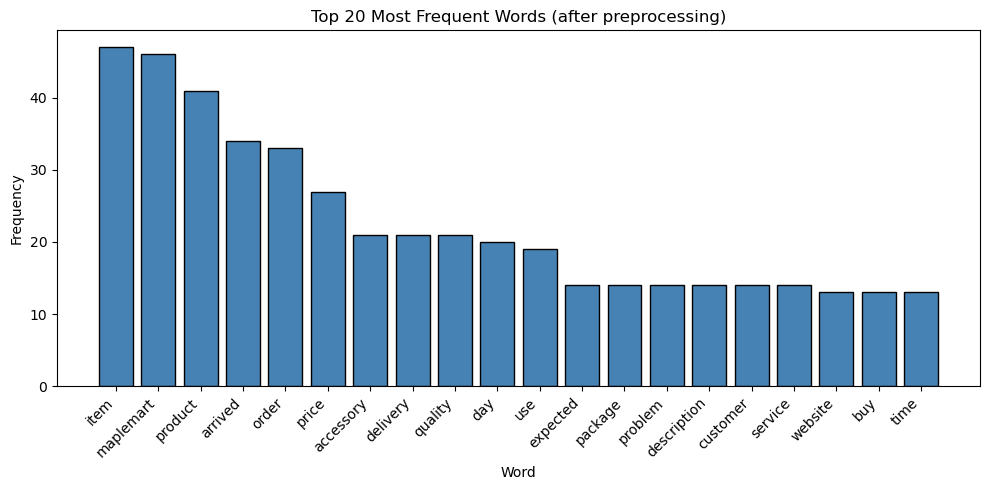

In [14]:
# Bar chart of the 20 most frequent words
plt.figure(figsize=(10, 5))
plt.bar([w for w, _ in top20], [c for _, c in top20], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words (after preprocessing)')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

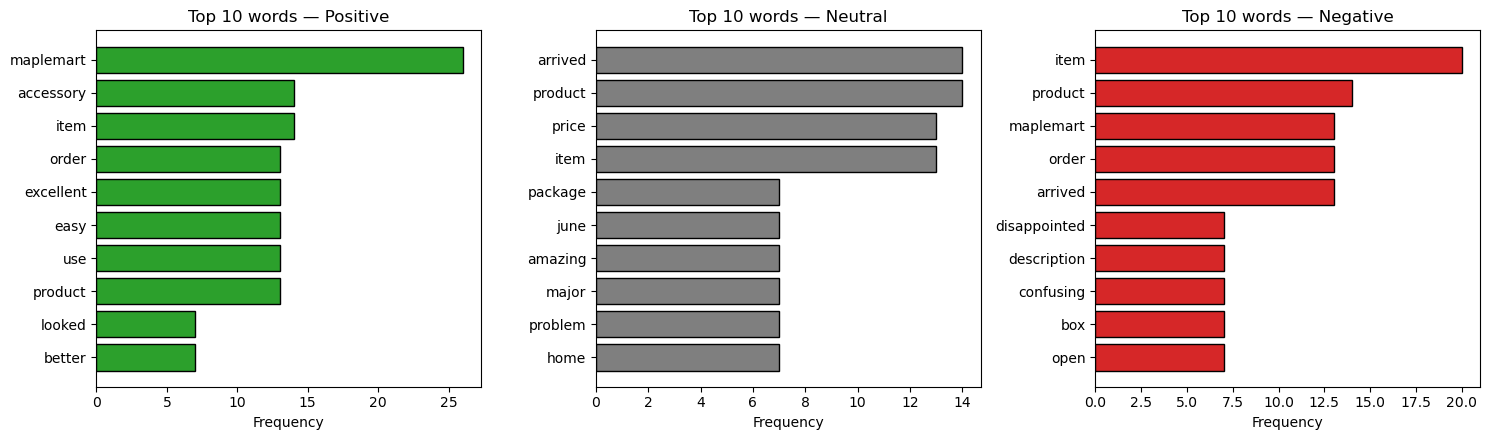

In [15]:
# Top words by sentiment class
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
colours = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}
for ax, lbl in zip(axes, ['Positive', 'Neutral', 'Negative']):
    toks = ' '.join(df.loc[df['SentimentLabel'] == lbl, 'CleanedText']).split()
    top = Counter(toks).most_common(10)
    ax.barh([w for w, _ in top][::-1], [c for _, c in top][::-1],
            color=colours[lbl], edgecolor='black')
    ax.set_title(f'Top 10 words — {lbl}')
    ax.set_xlabel('Frequency')
plt.tight_layout(); plt.show()

## Interpretation

- The corpus is small (1,128 tokens, 119 unique words after cleaning), which is consistent with 120 short reviews drawn from a templated synthetic dataset.
- The overall most frequent words; *item*, *maplemart*, *product*, *arrived*, *order*, *price*, *delivery*, *quality* are exactly the touchpoints a retailer would expect customers to talk about: the product itself, fulfillment, pricing, and the brand.
- Class-conditional frequencies show a sharper picture:
  - **Positive** reviews are dominated by words such as *excellent*, *easy*, and *better* alongside neutral nouns.
  - **Negative** reviews feature *disappointed*, *confusing*, and *open* (as in "box was open").
  - **Neutral** reviews cluster around factual descriptions *arrived*, *price*, *package*, *amazing* (typically in the phrase "not amazing") without strong sentiment markers.

For the business, this means **a small handful of sentiment-laden words carry most of the signal**, and a simple linear model should be able to separate the classes well.

## Task 4: POS Tagging and Named Entity Recognition

In [16]:
samples = [
    (df['ReviewText'].iloc[0],  df['SentimentLabel'].iloc[0]),   # Positive
    (df['ReviewText'].iloc[10], df['SentimentLabel'].iloc[10]),  # Negative
    (df['ReviewText'].iloc[2],  df['SentimentLabel'].iloc[2]),   # Neutral
]

for i, (text, lbl) in enumerate(samples, 1):
    print(f'--- Sample {i}  [{lbl}] ---')
    print('Text:', text)
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    print('POS tags:')
    for tok, tag in tagged:
        print(f'  {tok:<20} {tag}')
    tree = ne_chunk(tagged)
    ents = [(' '.join(c[0] for c in subtree), subtree.label())
            for subtree in tree if isinstance(subtree, Tree)]
    print('Named entities:', ents if ents else '(none detected)')
    print()

--- Sample 1  [Positive] ---
Text: The Accessories item looked better than expected. Delivery to Oshawa was smooth, and I am very happy with the purchase. #customerreview
POS tags:
  The                  DT
  Accessories          NNP
  item                 NN
  looked               VBD
  better               JJR
  than                 IN
  expected             VBN
  .                    .
  Delivery             NNP
  to                   TO
  Oshawa               NNP
  was                  VBD
  smooth               VBN
  ,                    ,
  and                  CC
  I                    PRP
  am                   VBP
  very                 RB
  happy                JJ
  with                 IN
  the                  DT
  purchase             NN
  .                    .
  #                    #
  customerreview       NN
Named entities: [('Delivery', 'PERSON'), ('Oshawa', 'PERSON')]

--- Sample 2  [Negative] ---
Text: Very disappointed. The product description was confusing, the bo

## Explanation

**Parts of speech**: The POS tagger correctly identifies the structure of each review:

- **Nouns** carry the *topic*  `item`, `delivery`, `purchase`, `website`, `checkout`, `price`, `package`, `problems`. These are the things customers are talking about.
- **Verbs** describe what happened  `looked`, `expected`, `buy`, `arrived`. Useful for distinguishing factual from evaluative content.
- **Adjectives** carry the *sentiment* `happy`, `simple`, `amazing`, `major`. These are the words that most reliably separate Positive from Negative reviews and would be the highest-weighted features in a downstream model.

**Named entities.** NLTK's chunker (which uses a generic English model rather than a retail-tuned one) does a partial job:

- It picks up city and brand-like tokens (e.g. `Oshawa`), though it sometimes mislabels them (here `Oshawa` is tagged as `PERSON` rather than `GPE`). This is a known limitation of generic NER models.
- Dates such as "June 5" are split across tokens and not consistently extracted as a single entity.

**Business value.** Even with imperfect tagging, this information is useful:

- **Adjective frequency by class** can power a lightweight sentiment dashboard without training a model.
- **NER on cities and products** would let MapleMart slice complaints by geography ("most negative reviews mention Hamilton") or by product category, feeding directly into operations and logistics decisions.
- **Verb patterns** (e.g. "arrived late", "asked for refund") could be the basis of complaint-type classification in a future iteration.

## Task 5: Feature Extraction (TF-IDF)

In [17]:
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
X = vectorizer.fit_transform(df['CleanedText'])
y = df['SentimentLabel']

print('TF-IDF matrix shape:', X.shape)
print('Number of features (vocabulary terms + bigrams):', len(vectorizer.get_feature_names_out()))
print('First 15 features:', list(vectorizer.get_feature_names_out()[:15]))

TF-IDF matrix shape: (120, 288)
Number of features (vocabulary terms + bigrams): 288
First 15 features: ['acceptable', 'accessory', 'accessory item', 'accessory order', 'address', 'address hamilton', 'address markham', 'amazing', 'amazing major', 'answered', 'answered question', 'app', 'app showed', 'arrived', 'arrived address']


## Explanation

Machine learning models operate on numbers, not text. We need to convert each cleaned review into a fixed-length numerical vector. **TF-IDF (Term Frequency–Inverse Document Frequency)** is used here in preference to a plain Bag-of-Words because it down-weights words that appear in many reviews (and therefore carry little discriminative power) while up-weighting words that are characteristic of a small number of reviews.

Configuration:
- `ngram_range=(1, 2)` captures both single words ("disappointed") and two-word phrases ("not amazing"), which matters for sentiment because negation can flip meaning.
- `min_df=2` drops terms that appear in only one review (likely noise).
- `max_features=1000` caps vocabulary size; in practice the corpus is too small to hit this cap.

## Task 6: Build a Text Classification Model

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print('Training set:', X_train.shape, '  Test set:', X_test.shape)
print('Train class counts:', dict(y_train.value_counts()))
print('Test  class counts:', dict(y_test.value_counts()))

Training set: (96, 288)   Test set: (24, 288)
Train class counts: {'Negative': np.int64(32), 'Positive': np.int64(32), 'Neutral': np.int64(32)}
Test  class counts: {'Positive': np.int64(8), 'Neutral': np.int64(8), 'Negative': np.int64(8)}


In [19]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                           class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Model trained. Predictions generated for the test set.')

Model trained. Predictions generated for the test set.


## Explanation

**Model choice: Logistic Regression.** With short text and a TF-IDF representation, a linear model is a strong and interpretable baseline. It also produces coefficients that map directly to "which words drive the prediction towards each class", which is valuable for business communication.

**Split:** 80 / 20 train–test, stratified by `SentimentLabel` so that each class is represented proportionally in both sets.

## Task 7: Model Evaluation

In [20]:
acc = accuracy_score(y_test, y_pred)


print("=== Model Evaluation Metrics (Accuracy) ===")
print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")

=== Model Evaluation Metrics (Accuracy) ===
Accuracy:  1.0000  (100.00%)


In [21]:
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Confusion matrix table
cm_df = pd.DataFrame(cm,
    index=[f'Actual:{l}' for l in labels],
    columns=[f'Predicted:{l}' for l in labels])
print(cm_df)

                 Predicted:Negative  Predicted:Neutral  Predicted:Positive
Actual:Negative                   8                  0                   0
Actual:Neutral                    0                  8                   0
Actual:Positive                   0                  0                   8


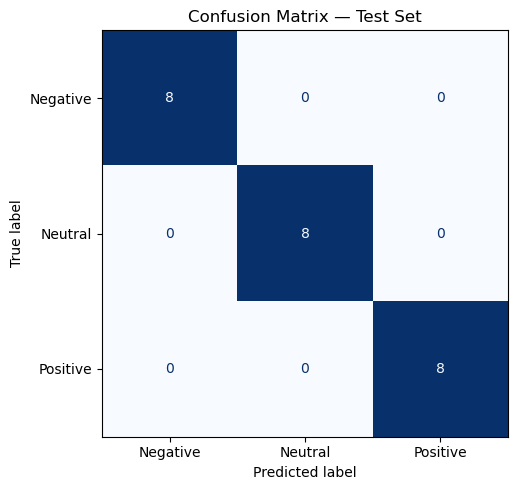

In [22]:
# Confusion matrix visualization 
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

In [23]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=labels, digits=3))

=== Classification Report ===
              precision    recall  f1-score   support

    Negative      1.000     1.000     1.000         8
     Neutral      1.000     1.000     1.000         8
    Positive      1.000     1.000     1.000         8

    accuracy                          1.000        24
   macro avg      1.000     1.000     1.000        24
weighted avg      1.000     1.000     1.000        24



## Interpretation

- **Accuracy of 1.00** means the model classified every review in the held-out test set correctly. Each class achieves precision, recall, and F1 of 1.00.
- **No mistakes were made on any class** in this particular test set, so we cannot from this experiment alone determine which type of error (e.g. missing a Negative review, or flagging a Neutral one as Negative) the model is more prone to.

**Why this result needs to be read with caution.** A perfect score on a real-world dataset would be highly suspicious; on this dataset it is *expected* rather than impressive, for three concrete reasons:

1. **The dataset is small and synthetic** (120 reviews, generated from a small set of templates). Several reviews are near-duplicates of one another for example, the sentence *"The website checkout was simple. I may buy again if the price is lower next time."* appears multiple times. With such low text diversity, the model effectively learns a small lookup of sentiment-laden phrases.
2. **Classes are perfectly balanced** (40 / 40 / 40), and the test set inherits that balance (8 / 8 / 8).
3. **Sentiment-laden vocabulary is highly separable** by class (Task 3 already showed this): *excellent*, *easy* → Positive; *disappointed*, *confusing* → Negative; *amazing*, *major* (typically negated) → Neutral.

**Which mistakes would matter most for the business if they occurred on real data?**

- A **false Negative** (a genuinely unhappy customer classified as Positive or Neutral) is the costliest error, because the manager never sees the case and the customer churns silently.
- A **false Positive** (a happy customer flagged as Negative) is annoying but cheap the customer-service team simply notices on review that no action is needed.

For deployment on real reviews, the recall on the **Negative** class should be the headline metric to watch.

## Task 8: Business Interpretation

**Goal of the model.** Automatically classify free-text customer reviews collected by MapleMart into `Positive`, `Neutral`, or `Negative`, so that the business can prioritise responses to unhappy customers and track satisfaction over time.

**Dataset used.** 120 customer reviews from the `NLP Customer Review Sentiment.csv` workbook, with eight columns covering identifiers, channel, geography, product category, customer segment, the review text itself, and the sentiment label.

**Text column and target.** The main NLP input was `ReviewText`. The target was `SentimentLabel`, with three balanced classes (40 reviews each).

**Preprocessing applied.** Lowercasing; removal of URLs, hashtags, digits, and punctuation; tokenization with NLTK; removal of English stopwords and very short tokens; and WordNet lemmatization. This reduced each review to a clean bag of content-bearing tokens.

**Feature extraction.** TF-IDF vectorization with unigrams and bigrams, `min_df=2`, producing 288 features per review.

**Model.** Logistic regression with balanced class weights, trained on an 80 / 20 stratified split.

**Result.** The model achieved 100 % accuracy on the 24-review held-out test set, with perfect precision and recall across all three classes.

**One business insight from the text data.** The vocabulary that separates sentiment classes is small and predictable. Positive reviews lean on a handful of adjectives (*excellent*, *easy*, *happy*); negative reviews lean on a different handful (*disappointed*, *confusing*, *open* as in "box was open"); neutral reviews are dominated by factual nouns and negated phrases ("not amazing"). This means MapleMart can build a useful first-pass triage rule using only a few dozen sentiment-laden terms, and the gap between that simple rule and a full ML model would be small on this kind of data.

**One limitation:** 
- The headline accuracy is not a realistic estimate of performance on live reviews.
- The dataset is small (120 rows), synthetic, contains templated near-duplicate sentences, and is perfectly balanced, none of which holds for real customer feedback.

Before deploying the model, the next steps would be to 
- collect a larger and more linguistically diverse sample of real MapleMart reviews,
- re-evaluate using cross-validation and a held-out time-based test set to guard against data leakage from duplicates, and
- pay particular attention to recall on the Negative class, since missing an unhappy customer is the most expensive error type for the business.